# TruthGuard — Notebook 1/5
## Étape 1 : Installation, Chargement des données & EDA Labels

> ** Version corrigée** — Résolution du problème NLTK `[Errno 11001] getaddrinfo failed` (pas d'accès internet) via téléchargement manuel des ressources.

## 1. Installation des packages Python

In [5]:
%pip install nltk wordcloud sentence-transformers shap langdetect --break-system-packages -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2.  Résolution du problème NLTK (hors ligne)

### Pourquoi l'erreur se produit ?
```
[nltk_data] Error loading punkt: <urlopen error [Errno 11001] getaddrinfo failed>
```
NLTK essaie de se connecter à `https://raw.githubusercontent.com/nltk/...` pour télécharger ses données.  
Si votre réseau bloque les connexions sortantes (proxy d'entreprise, VPN, restriction firewall), la résolution DNS échoue.

### Solution retenue : téléchargement manuel via `urllib` avec fallback
On télécharge les archives ZIP directement depuis GitHub et on les place dans le dossier NLTK local, **sans passer par le downloader NLTK**.

In [6]:

import os, sys, zipfile, urllib.request, ssl
from pathlib import Path
import nltk

# ── Dossier de stockage NLTK (peut être changé)
NLTK_DATA_DIR = Path.home() / "nltk_data"
NLTK_DATA_DIR.mkdir(parents=True, exist_ok=True)

# Informer NLTK de ce chemin
if str(NLTK_DATA_DIR) not in nltk.data.path:
    nltk.data.path.insert(0, str(NLTK_DATA_DIR))

# ── Ressources nécessaires : (nom_package, sous_dossier_nltk, fichier_attendu)
RESOURCES = [
    ("punkt",                      "tokenizers",  "punkt"),
    ("punkt_tab",                  "tokenizers",  "punkt_tab"),
    ("stopwords",                  "corpora",     "stopwords"),
    ("wordnet",                    "corpora",     "wordnet"),
    ("omw-1.4",                    "corpora",     "omw-1.4"),
    ("averaged_perceptron_tagger", "taggers",     "averaged_perceptron_tagger"),
    ("averaged_perceptron_tagger_eng", "taggers", "averaged_perceptron_tagger_eng"),
]

# ── Contexte SSL sans vérification (contourne certains proxies)
ssl_ctx = ssl.create_default_context()
ssl_ctx.check_hostname = False
ssl_ctx.verify_mode    = ssl.CERT_NONE

def resource_exists(sub_dir: str, name: str) -> bool:
    """Vérifie si la ressource est déjà présente localement."""
    target = NLTK_DATA_DIR / sub_dir / name
    return target.exists()

def download_resource_manual(package: str, sub_dir: str) -> bool:
    """Télécharge une ressource NLTK depuis GitHub (ZIP) et la décompresse."""
    dest_dir = NLTK_DATA_DIR / sub_dir
    dest_dir.mkdir(parents=True, exist_ok=True)
    zip_path = dest_dir / f"{package}.zip"

    urls = [
        f"https://raw.githubusercontent.com/nltk/nltk_data/gh-pages/packages/{sub_dir}/{package}.zip",
        f"https://github.com/nltk/nltk_data/raw/gh-pages/packages/{sub_dir}/{package}.zip",
    ]
    for url in urls:
        try:
            print(f"  ↓ Téléchargement : {package} ...", end=" ", flush=True)
            req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
            with urllib.request.urlopen(req, context=ssl_ctx, timeout=30) as r, \
                 open(zip_path, "wb") as f:
                f.write(r.read())
            with zipfile.ZipFile(zip_path, "r") as z:
                z.extractall(dest_dir)
            zip_path.unlink(missing_ok=True)
            return True
        except Exception as e:
            print(f"\n      URL échouée ({url[:60]}...) : {e}")
    return False

print("═" * 55)
print("  INSTALLATION DES RESSOURCES NLTK")
print("═" * 55)

failed = []
for package, sub_dir, check_name in RESOURCES:
    if resource_exists(sub_dir, check_name):
        print(f"   {package:<40} déjà présent")
    else:
        # Essai 1 — downloader NLTK standard
        try:
            ok = nltk.download(package, download_dir=str(NLTK_DATA_DIR), quiet=True)
        except Exception:
            ok = False

        if resource_exists(sub_dir, check_name):
            print(f"   {package:<40} téléchargé (méthode NLTK)")
        else:
            # Essai 2 — téléchargement manuel
            success = download_resource_manual(package, sub_dir)
            if not success:
                failed.append((package, sub_dir))

if failed:
    print("\n" + "═" * 55)
    print("  Ressources non téléchargées (réseau toujours bloqué) :")
    for p, s in failed:
        print(f"     • {p}  →  sous-dossier : {s}")
    print("")
else:
    print("\n  Toutes les ressources NLTK sont disponibles !")

═══════════════════════════════════════════════════════
  INSTALLATION DES RESSOURCES NLTK
═══════════════════════════════════════════════════════
   punkt                                    déjà présent
   punkt_tab                                déjà présent
   stopwords                                déjà présent
   wordnet                                  déjà présent
   omw-1.4                                  déjà présent
   averaged_perceptron_tagger               déjà présent
   averaged_perceptron_tagger_eng           déjà présent

  Toutes les ressources NLTK sont disponibles !


## 3. Imports & configuration globale

In [14]:
import os, re, string, warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

import nltk

# ── S'assurer que NLTK cherche bien dans notre dossier local
NLTK_DATA_DIR = Path.home() / "nltk_data"
if str(NLTK_DATA_DIR) not in nltk.data.path:
    nltk.data.path.insert(0, str(NLTK_DATA_DIR))

# ── Imports NLTK avec fallbacks gracieux
try:
    from nltk.corpus import stopwords
    STOP_WORDS = set(stopwords.words("english"))
    print(" stopwords chargés")
except LookupError:
    print("  stopwords introuvable — utilisation d'une liste de secours")
    STOP_WORDS = set([
        "i","me","my","myself","we","our","ours","ourselves","you","your",
        "he","him","his","she","her","it","its","they","them","their",
        "what","which","who","this","that","these","those","am","is","are",
        "was","were","be","been","being","have","has","had","do","does","did",
        "will","would","could","should","may","might","shall","can","not",
        "and","but","or","nor","so","yet","both","either","neither",
        "a","an","the","in","on","at","by","for","with","of","to","from",
        "up","about","into","through","during","before","after","above",
        "below","between","out","off","over","under","again","then","once",
        "here","there","when","where","why","how","all","each","every",
        "few","more","most","other","some","such","no","only","same",
        "than","too","very","just","because","as","while","although"
    ])

try:
    from nltk.tokenize import word_tokenize, sent_tokenize
    _test = word_tokenize("Test sentence.")
    print(" WordTokenizer chargés")
    USE_NLTK_TOKENIZE = True
except LookupError:
    print("  punkt introuvable — utilisation de tokenizers de secours")
    USE_NLTK_TOKENIZE = False
    def word_tokenize(text):
        """Tokenizer de secours basé sur regex."""
        return re.findall(r"\b[a-zA-Z']+\b", str(text).lower())
    def sent_tokenize(text):
        """Segmenteur de phrases de secours basé sur regex."""
        return re.split(r'(?<=[.!?])\s+', str(text).strip())

try:
    from nltk.stem import WordNetLemmatizer
    _lemmatizer = WordNetLemmatizer()
    _lemmatizer.lemmatize("running")  # test
    print(" WordNetLemmatizer chargé")
    USE_LEMMATIZER = True
except LookupError:
    print("  wordnet introuvable — lemmatisation désactivée (on utilisera le stemming regex)")
    USE_LEMMATIZER = False

try:
    from nltk import pos_tag
    pos_tag(["test"])
    print(" POS tagger chargé")
    USE_POS = True
except LookupError:
    print("  averaged_perceptron_tagger introuvable — POS tagging désactivé")
    USE_POS = False

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split

try:
    from wordcloud import WordCloud
    USE_WORDCLOUD = True
except ImportError:
    USE_WORDCLOUD = False
    print(" wordcloud non installé — nuages de mots désactivés")

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11

# ── Chemins (à adapter si besoin)
BASE_DIR = Path.cwd().resolve()
DATA_DIR = None
while BASE_DIR != BASE_DIR.parent:
    candidate = BASE_DIR / 'notebook' / 'Fake_news_net' / 'data'
    if candidate.exists():
        DATA_DIR = candidate
        break
    BASE_DIR = BASE_DIR.parent

if DATA_DIR is None:
    raise FileNotFoundError(f"Impossible de trouver notebook/Fake_news_net/data depuis {Path.cwd().resolve()}")

OUT_DIR = BASE_DIR / 'notebook' / 'Fake_news_net' / 'output'
OUT_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42

print(f"Configuration terminée. DATA_DIR={DATA_DIR}")

 stopwords chargés
 WordTokenizer chargés
 WordNetLemmatizer chargé
 POS tagger chargé
Configuration terminée. DATA_DIR=C:\Users\PC\fake-news-app\notebook\Fake_news_net\data


## 4. Chargement et fusion des données

In [15]:
COLS_TO_DROP = ["url", "top_img", "authors", "id", "publish_date", "source",
                "movies", "images", "canonical_link", "meta_data"]

def load_and_prepare(filepath: Path, label: int, source_name: str,
                     extra_drop: list = None) -> pd.DataFrame:
    """Charge un CSV, crée la colonne 'statement' et ajoute les métadonnées."""
    df = pd.read_csv(filepath, engine='python', on_bad_lines='warn')
    cols_present = [c for c in (COLS_TO_DROP + (extra_drop or [])) if c in df.columns]
    df.drop(columns=cols_present, inplace=True)
    df["label"]     = label
    df["statement"] = df["title"].fillna("") + " " + df["text"].fillna("")
    df["source_df"] = source_name
    df.drop(columns=[c for c in ["title", "text"] if c in df.columns], inplace=True)
    return df

df_fnn = pd.concat([
    load_and_prepare(DATA_DIR / "BuzzFeed_fake_news_content.csv",   0, "buzzfeed"),
    load_and_prepare(DATA_DIR / "BuzzFeed_real_news_content.csv",   1, "buzzfeed"),
    load_and_prepare(DATA_DIR / "PolitiFact_fake_news_content.csv", 0, "politifact"),
    load_and_prepare(DATA_DIR / "PolitiFact_real_news_content.csv", 1, "politifact"),
], axis=0).sample(frac=1, random_state=SEED).reset_index(drop=True)

df_raw = df_fnn.copy()

print(f"FakeNewsNet (BuzzFeed + PolitiFact) : {df_raw.shape[0]:>6} lignes")
df_raw.head(3)

FakeNewsNet (BuzzFeed + PolitiFact) :    422 lignes


,label,statement,source_df
0,1,Kaine visits site of Orlando mass shooting Tim...,buzzfeed
1,1,Christie among the most unpopular governors in...,politifact
2,1,McAuliffe hangs with Willie Nelson -- and his ...,buzzfeed


## 5. EDA — Vue d'ensemble du dataset

In [16]:
print("═" * 50)
print(" APERÇU GÉNÉRAL DU DATASET BRUT")
print("═" * 50)
print(f"\n• Dimensions    : {df_raw.shape}")
print(f"• Colonnes      : {list(df_raw.columns)}")
print(f"• Types         :\n{df_raw.dtypes}")
print(f"\n• Valeurs nulles par colonne :")
print(df_raw.isnull().sum())
print(f"\n• Doublons (statement identique) : {df_raw.duplicated(subset='statement').sum()}")

══════════════════════════════════════════════════
 APERÇU GÉNÉRAL DU DATASET BRUT
══════════════════════════════════════════════════

• Dimensions    : (422, 3)
• Colonnes      : ['label', 'statement', 'source_df']
• Types         :
label        int64
statement      str
source_df      str
dtype: object

• Valeurs nulles par colonne :
label        0
statement    0
source_df    0
dtype: int64

• Doublons (statement identique) : 133


In [17]:
# ── Métriques textuelles (robustes : utilisent les fallbacks si NLTK absent)
df_raw["char_count"]   = df_raw["statement"].str.len()
df_raw["word_count"]   = df_raw["statement"].str.split().str.len()
df_raw["sent_count"]   = df_raw["statement"].apply(lambda x: len(sent_tokenize(str(x))))
df_raw["avg_word_len"] = df_raw["statement"].apply(
    lambda x: np.mean([len(w) for w in str(x).split()]) if str(x).split() else 0
)

print(df_raw[["char_count", "word_count", "sent_count", "avg_word_len"]].describe().round(2))

       char_count  word_count  sent_count  avg_word_len
count      422.00      422.00      422.00        422.00
mean      3670.87      604.67       26.08          4.99
std       4171.01      679.42       26.25          0.26
min         63.00       10.00        1.00          4.32
25%       1695.00      275.75       12.00          4.82
50%       2394.00      406.50       18.00          4.99
75%       3628.25      600.00       30.75          5.16
max      32658.00     5468.00      211.00          5.99


## 6. EDA — Analyse des labels

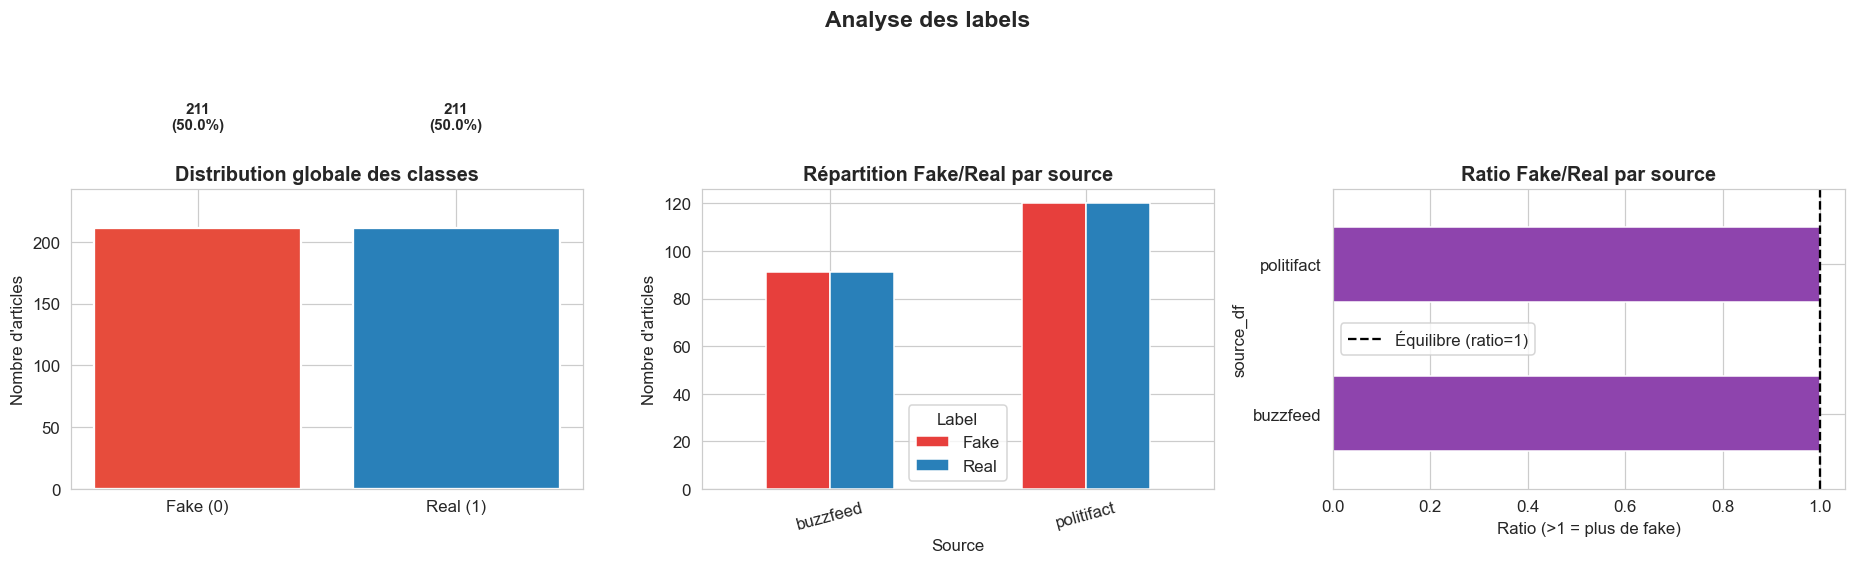


  Ratio déséquilibre (min/max) : 1.000
   → Dataset relativement équilibré.


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

label_counts = df_raw["label"].value_counts().sort_index()
label_names  = ["Fake (0)", "Real (1)"]
colors       = ["#e74c3c", "#2980b9"]

# — Graphe 1 : distribution globale
bars = axes[0].bar(label_names, label_counts.values,
                   color=colors, edgecolor="white", linewidth=1.5)
for bar, val in zip(bars, label_counts.values):
    pct = val / label_counts.sum() * 100
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 80,
                 f"{val:,}\n({pct:.1f}%)",
                 ha="center", fontsize=10, fontweight="bold")
axes[0].set_title("Distribution globale des classes", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Nombre d'articles")
axes[0].set_ylim(0, label_counts.max() * 1.15)

# — Graphe 2 : répartition par source
src_label = df_raw.groupby(["source_df", "label"]).size().unstack(fill_value=0)
src_label.columns = ["Fake", "Real"]
src_label.plot(kind="bar", ax=axes[1],
               color=["#e73f3c", "#2980b9"],
               edgecolor="white", linewidth=1)
axes[1].set_title("Répartition Fake/Real par source", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Source")
axes[1].set_ylabel("Nombre d'articles")
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend(title="Label")

# — Graphe 3 : ratio Fake/Real par source
src_ratio = src_label["Fake"] / (src_label["Real"] + 1e-9)
src_ratio.plot(kind="barh", ax=axes[2], color="#8e44ad", edgecolor="white")
axes[2].axvline(x=1.0, color="black", linestyle="--", linewidth=1.5, label="Équilibre (ratio=1)")
axes[2].set_title("Ratio Fake/Real par source", fontsize=13, fontweight="bold")
axes[2].set_xlabel("Ratio (>1 = plus de fake)")
axes[2].legend()

plt.suptitle("Analyse des labels", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR / "01_label_analysis.png", bbox_inches="tight", dpi=150)
plt.show()

ratio = label_counts.min() / label_counts.max()
print(f"\n  Ratio déséquilibre (min/max) : {ratio:.3f}")
if ratio < 0.7:
    print("   → Déséquilibre détecté : utiliser class_weight='balanced' ou sur-/sous-échantillonnage.")
else:
    print("   → Dataset relativement équilibré.")

## 7. EDA — Analyse textuelle par label

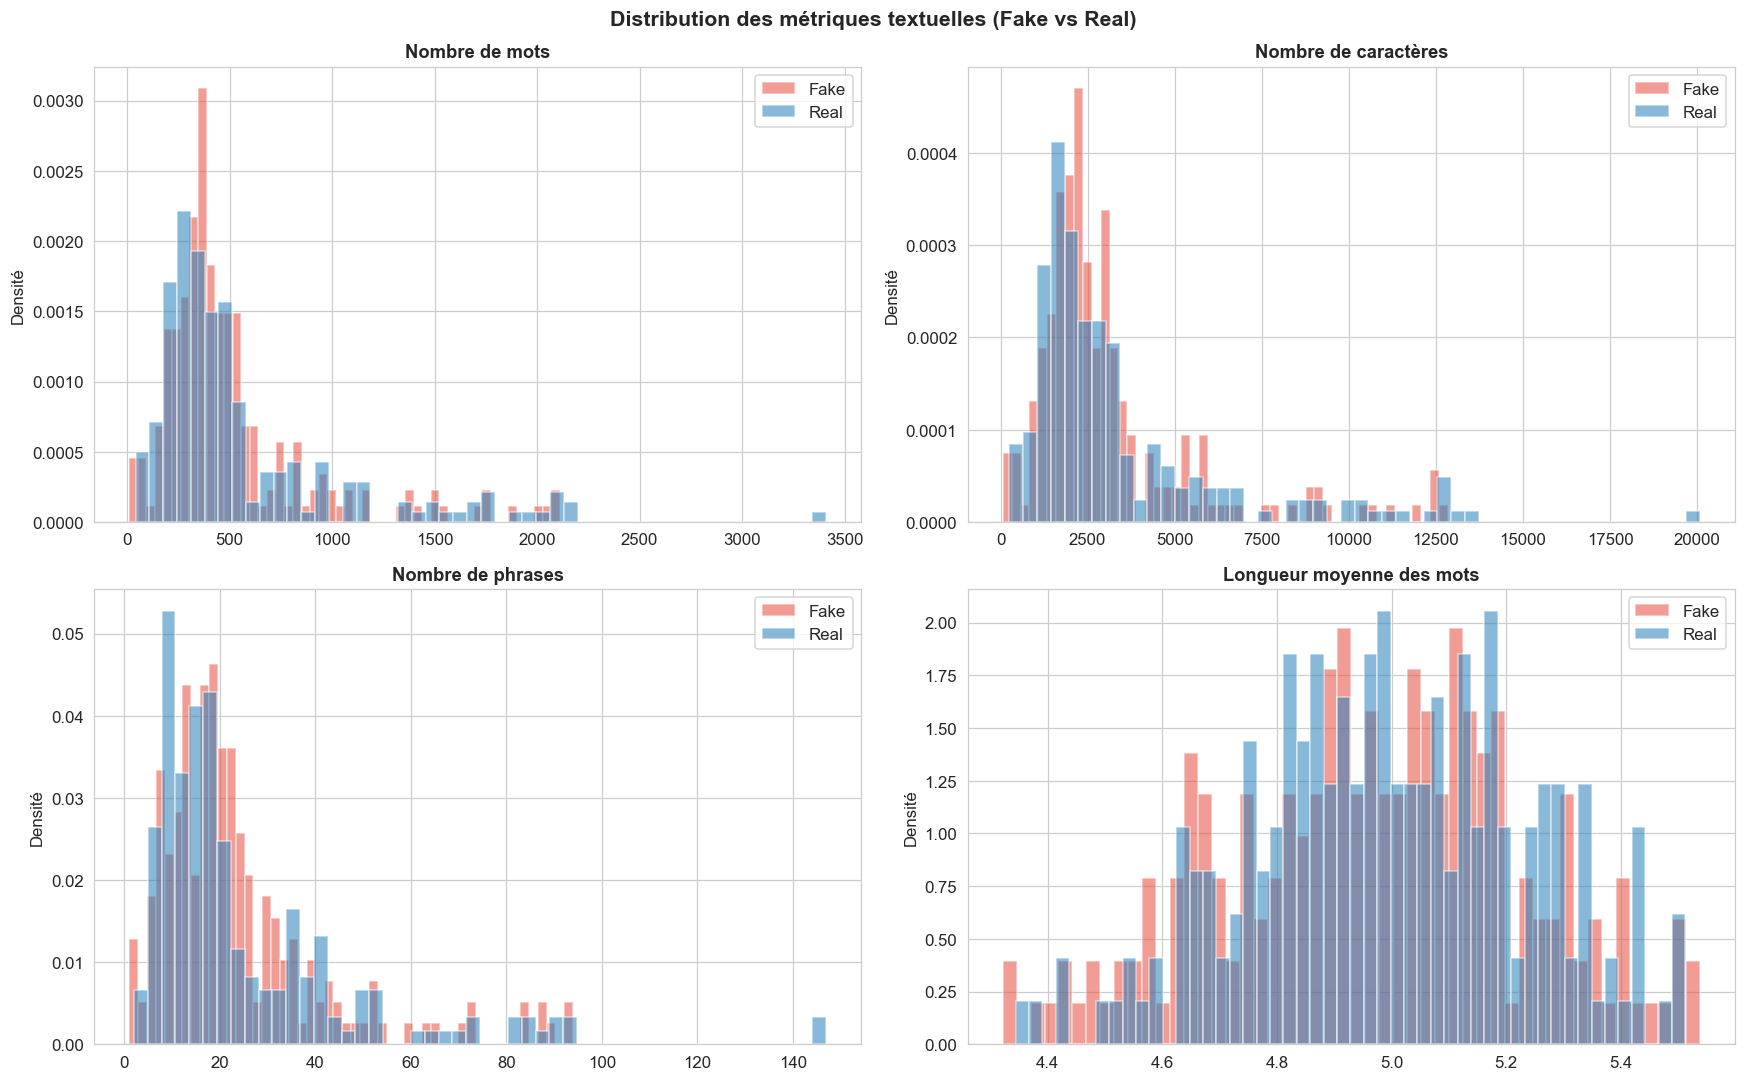

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

metrics = [
    ("word_count",   "Nombre de mots"),
    ("char_count",   "Nombre de caractères"),
    ("sent_count",   "Nombre de phrases"),
    ("avg_word_len", "Longueur moyenne des mots"),
]

for ax, (col, title) in zip(axes, metrics):
    for lbl, color, name in [(0, "#e74c3c", "Fake"), (1, "#2980b9", "Real")]:
        data = df_raw.loc[df_raw["label"] == lbl, col].dropna()
        # Clamp à 99e percentile pour éviter les outliers extrêmes
        cap = data.quantile(0.99)
        data = data[data <= cap]
        ax.hist(data, bins=50, alpha=0.55, color=color, label=name, density=True)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.legend()
    ax.set_ylabel("Densité")

plt.suptitle("Distribution des métriques textuelles (Fake vs Real)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "01_text_metrics.png", bbox_inches="tight", dpi=150)
plt.show()

## 8. Nuages de mots (si wordcloud disponible)

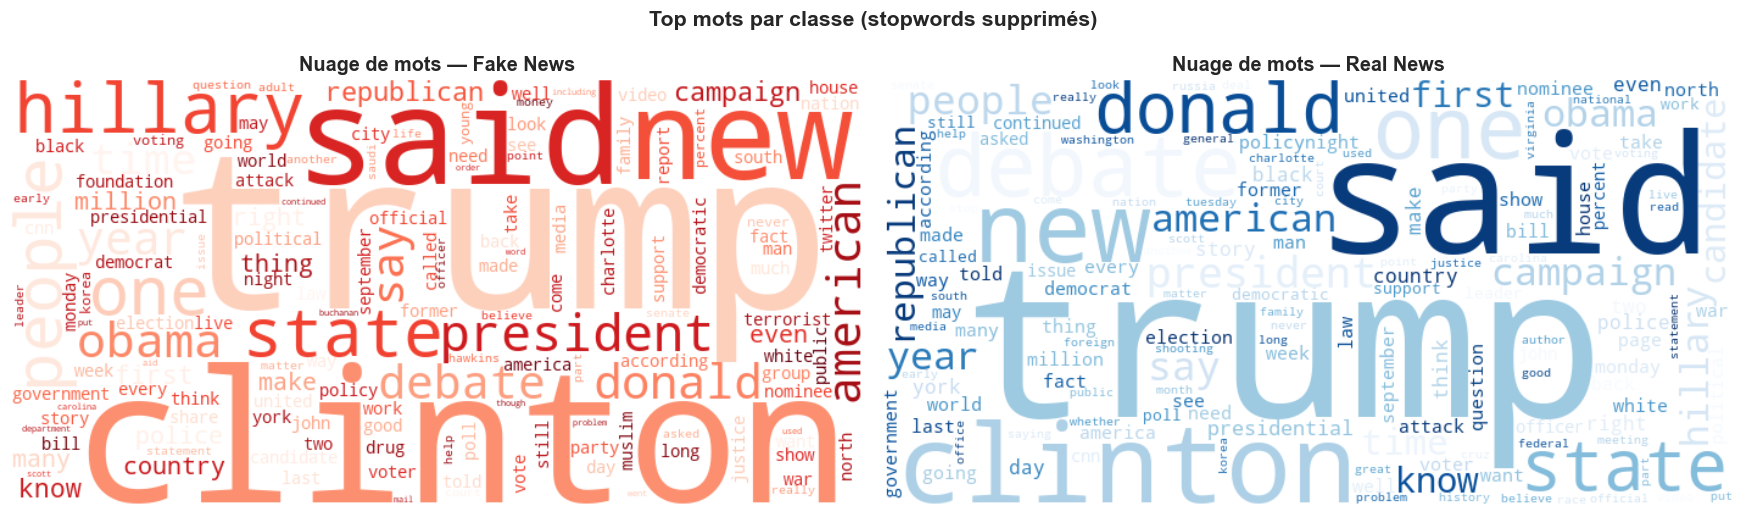

In [20]:
def simple_clean(text: str) -> str:
    """Nettoyage basique sans dépendance NLTK."""
    text = str(text).lower()
    text = re.sub(r"https?://\S+", "", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    tokens = [w for w in text.split() if w not in STOP_WORDS and len(w) > 2]
    return " ".join(tokens)

if USE_WORDCLOUD:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    for ax, lbl, title, cmap in [
        (axes[0], 0, "Fake News",  "Reds"),
        (axes[1], 1, "Real News",  "Blues"),
    ]:
        corpus = " ".join(df_raw.loc[df_raw["label"] == lbl, "statement"]
                          .apply(simple_clean).tolist())
        wc = WordCloud(width=700, height=350, background_color="white",
                       colormap=cmap, max_words=150,
                       collocations=False).generate(corpus)
        ax.imshow(wc, interpolation="bilinear")
        ax.axis("off")
        ax.set_title(f"Nuage de mots — {title}", fontsize=13, fontweight="bold")
    plt.suptitle("Top mots par classe (stopwords supprimés)",
                 fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "01_wordclouds.png", bbox_inches="tight", dpi=150)
    plt.show()
else:
    print("wordcloud non disponible — cette cellule est ignorée.")
    print("Installez-le avec :  pip install wordcloud --break-system-packages")

## 9. Top mots TF-IDF par classe (sans NLTK)

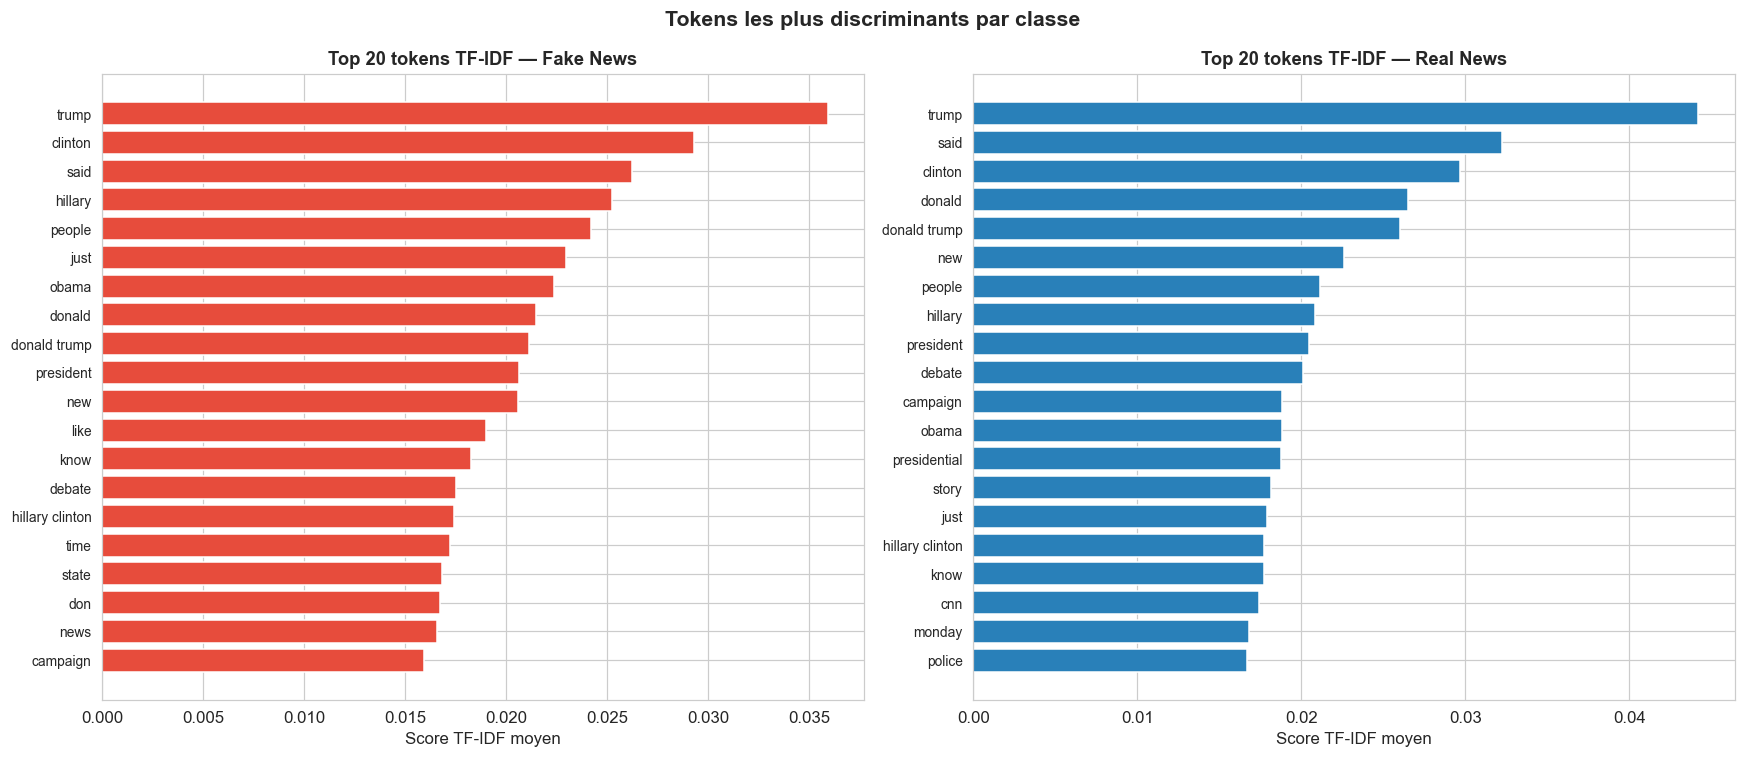

In [21]:
# TF-IDF utilise sklearn — aucune dépendance NLTK
tfidf = TfidfVectorizer(
    max_features=10_000,
    stop_words="english",   # liste interne sklearn
    ngram_range=(1, 2),
    min_df=5,
    sublinear_tf=True
)

X_tfidf = tfidf.fit_transform(df_raw["statement"].fillna(""))
feature_names = np.array(tfidf.get_feature_names_out())

N_TOP = 20
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, lbl, title, color in [
    (axes[0], 0, "Fake News",  "#e74c3c"),
    (axes[1], 1, "Real News",  "#2980b9"),
]:
    mask = df_raw["label"].to_numpy() == lbl

    class_tfidf = X_tfidf[mask]
    mean_scores = np.asarray(class_tfidf.mean(axis=0)).ravel()
    top_n = min(N_TOP, mean_scores.size)
    top_idx = np.argsort(mean_scores)[-top_n:][::-1]
    top_words   = feature_names[top_idx]
    top_scores  = mean_scores[top_idx]

    ax.barh(range(N_TOP), top_scores[::-1], color=color, edgecolor="white")
    ax.set_yticks(range(N_TOP))
    ax.set_yticklabels(top_words[::-1], fontsize=9)
    ax.set_title(f"Top {N_TOP} tokens TF-IDF — {title}",
                 fontsize=12, fontweight="bold")
    ax.set_xlabel("Score TF-IDF moyen")

plt.suptitle("Tokens les plus discriminants par classe",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "01_tfidf_top_words.png", bbox_inches="tight", dpi=150)
plt.show()

## 10. Sauvegarde du dataset annoté

In [23]:
from pathlib import Path

# chemin du dossier data
OUT_DIR = DATA_DIR

# créer le dossier s'il n'existe pas
OUT_DIR.mkdir(parents=True, exist_ok=True)

# fichier final
OUT_CSV = OUT_DIR / "df_raw_annotated.csv"

# sauvegarde
df_raw.to_csv(OUT_CSV, index=False)

print(f" Dataset sauvegardé : {OUT_CSV}")
print(f"   Shape : {df_raw.shape}")
print(f"   Colonnes : {list(df_raw.columns)}")

print("Ce fichier sera chargé dans le Notebook 2 (Nettoyage & Prétraitement).")


 Dataset sauvegardé : C:\Users\PC\fake-news-app\notebook\Fake_news_net\data\df_raw_annotated.csv
   Shape : (422, 7)
   Colonnes : ['label', 'statement', 'source_df', 'char_count', 'word_count', 'sent_count', 'avg_word_len']
Ce fichier sera chargé dans le Notebook 2 (Nettoyage & Prétraitement).


## Récapitulatif des corrections apportées

| Problème | Solution |
|---|---|
| `getaddrinfo failed` lors du download NLTK | Téléchargement manuel via `urllib` avec contexte SSL assoupli |
| Dépendance dure aux ressources NLTK | Fallbacks intégrés pour `word_tokenize`, `sent_tokenize`, `stopwords` |
| Crash si `wordcloud` absent | Vérification d'import + cellule conditionnelle |
| Pas de sauvegarde des figures | `plt.savefig()` ajouté sur chaque graphe |
| `OUT_DIR` non créé | `OUT_DIR.mkdir(parents=True, exist_ok=True)` ajouté |

### Si le réseau reste totalement bloqué (Méthode B)
Téléchargez les ZIP NLTK sur un autre ordinateur depuis :
```
https://github.com/nltk/nltk_data/tree/gh-pages/packages
```
Puis copiez les dossiers extraits dans `C:\Users\mouss\nltk_data\` :
```
nltk_data/
├── tokenizers/
│   ├── punkt/
│   └── punkt_tab/
├── corpora/
│   ├── stopwords/
│   ├── wordnet/
│   └── omw-1.4/
└── taggers/
    ├── averaged_perceptron_tagger/
    └── averaged_perceptron_tagger_eng/
```